# LAS → TVD Calculator → CSV Exporter

**Steps:**
1. Imports & helpers
2. Set file paths
3. Load LAS & trajectory
4. Select logs
5. Export to CSV

In [3]:
# ── Cell 2: Imports & helper functions ──────────────────────────────────
import re
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.interpolate import interp1d
import lasio
import ipywidgets as widgets
from IPython.display import display, HTML

FEET_UNITS  = {"ft", "feet", "foot", "f"}
METRE_UNITS = {"m", "meter", "metre", "meters", "metres"}

def _ft_to_m(v): return v * 0.3048

# ── Hardcoded EGL (ground level elevation) ────────────────────────────────
EGL_FT = 5536.0          # ft  ← change if needed
EGL_M  = EGL_FT * 0.3048 # converted to metres automatically

def load_las(path):
    las  = lasio.read(path)
    well = las.well["WELL"].value if "WELL" in las.well else "N/A"
    print(f"  Well      : {well}")
    print(f"  Curves    : {[c.mnemonic for c in las.curves]}")
    print(f"  Depth unit: {las.curves[0].unit if las.curves else '?'}")
    return las

def get_depth_in_metres(las):
    dept_curve = las.curves[0]
    depth_raw  = dept_curve.data.copy()
    dept_unit  = (dept_curve.unit or "").strip().lower()

    if dept_unit in FEET_UNITS:
        depth_m = depth_raw * 0.3048
        print("  Depth converted: ft \u2192 m")
    elif dept_unit in METRE_UNITS:
        depth_m = depth_raw.copy()
        print("  Depth already in metres")
    else:
        print(f"  \u26a0 Unknown depth unit '{dept_unit}' \u2013 assuming feet")
        depth_m = depth_raw * 0.3048

    print(f"  EGL: {EGL_FT} ft \u2192 {EGL_M:.3f} m  (hardcoded)")
    return depth_m, dept_unit, EGL_M

def _minimum_curvature(md, inc_deg, az_deg):
    """
    Calculate TVD, N-S, E-W from MD, inclination, azimuth
    using the minimum curvature method.
    All inputs in feet and degrees. Returns arrays in feet.
    """
    inc = np.radians(inc_deg)
    az  = np.radians(az_deg)
    n   = len(md)

    tvd = np.zeros(n)
    ns  = np.zeros(n)
    ew  = np.zeros(n)

    for i in range(1, n):
        dmd = md[i] - md[i-1]
        i1, i2 = inc[i-1], inc[i]
        a1, a2 = az[i-1],  az[i]

        dl = np.arccos(np.cos(i2 - i1) - np.sin(i1)*np.sin(i2)*(1 - np.cos(a2 - a1)))
        rf = (2.0 / dl * np.tan(dl / 2.0)) if dl > 1e-10 else 1.0

        tvd[i] = tvd[i-1] + dmd/2 * (np.cos(i1) + np.cos(i2)) * rf
        ns[i]  = ns[i-1]  + dmd/2 * (np.sin(i1)*np.cos(a1) + np.sin(i2)*np.cos(a2)) * rf
        ew[i]  = ew[i-1]  + dmd/2 * (np.sin(i1)*np.sin(a1) + np.sin(i2)*np.sin(a2)) * rf

    return tvd, ns, ew

def load_trajectory(path, sep=";"):
    """
    Load trajectory CSV and compute TVD, N-S, E-W using minimum curvature.
    Required columns: Measured Depth, Inclination, Azimuth.
    Decimal separator is always '.'. sep = column delimiter (default ';').
    """
    try:
        df = pd.read_csv(path, sep=sep, decimal=".", skipinitialspace=True, engine="python")
    except Exception as e:
        raise ValueError(f"Could not read trajectory file: {e}")

    # Clean embedded newlines in headers and thousand-separator commas in values
    df.columns = [c.replace("\n", " ").strip() for c in df.columns]
    for col in df.columns:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", "", regex=False),
            errors="coerce"
        )

    print(f"  Delimiter  : {repr(sep)}  |  Decimal: '.'")
    print(f"  Columns    : {list(df.columns)}")
    print(f"  Rows       : {len(df)}")

    # Identify required columns
    md_col = inc_col = az_col = None
    for c in df.columns:
        cl = c.lower()
        if "measured" in cl or cl.startswith("md"):
            md_col = c
        elif "inclin" in cl or cl.startswith("inc"):
            inc_col = c
        elif "azimuth" in cl or cl.startswith("az"):
            az_col = c

    for label, col in [("Measured Depth", md_col), ("Inclination", inc_col), ("Azimuth", az_col)]:
        if col is None:
            raise ValueError(f"Could not find '{label}' column.\nColumns available: {list(df.columns)}")

    print(f"  MD col     : '{md_col}'")
    print(f"  Inc col    : '{inc_col}'")
    print(f"  Az col     : '{az_col}'")

    # Infer unit from MD column header
    unit_match = re.search(r'\((\w+)\)', md_col)
    traj_unit  = unit_match.group(1).lower() if unit_match else "ft"
    print(f"  Traj unit  : {traj_unit}")

    df = df.dropna(subset=[md_col, inc_col, az_col])
    if len(df) == 0:
        raise ValueError("No valid rows after dropping NaN in MD/Inc/Az columns.")

    md_raw  = df[md_col].values
    inc_raw = df[inc_col].values
    az_raw  = df[az_col].values

    # Calculate TVD, N-S, E-W using minimum curvature
    tvd_raw, ns_raw, ew_raw = _minimum_curvature(md_raw, inc_raw, az_raw)

    factor = 0.3048 if traj_unit in FEET_UNITS else 1.0
    result = pd.DataFrame({
        "MD_m"  : md_raw  * factor,
        "TVD_m" : tvd_raw * factor,
        "NS_m"  : ns_raw  * factor,
        "EW_m"  : ew_raw  * factor,
    })

    print(f"  MD range   : {result['MD_m'].min():.1f} \u2013 {result['MD_m'].max():.1f} m")
    print(f"  TVD range  : {result['TVD_m'].min():.1f} \u2013 {result['TVD_m'].max():.1f} m")
    print("  \u2713 TVD calculated via minimum curvature")
    return result, traj_unit

def interpolate_tvd(depth_m, traj_df, egl_m=None):
    """
    Interpolate TVD, NS, EW at every LAS depth point using MD as the index.
    depth_m : LAS measured depth array (metres)
    traj_df : trajectory dataframe with MD_m, TVD_m, NS_m, EW_m
    egl_m   : elevation ground level in metres (for TVD_SS)
    """
    md  = traj_df["MD_m"].values
    tvd = traj_df["TVD_m"].values
    ns  = traj_df["NS_m"].values
    ew  = traj_df["EW_m"].values

    if len(md) == 0:
        raise ValueError("Trajectory is empty \u2013 cannot interpolate.")

    kw    = dict(kind="linear", bounds_error=False)
    f_tvd = interp1d(md, tvd, fill_value=(tvd[0], tvd[-1]), **kw)
    f_ns  = interp1d(md, ns,  fill_value=(ns[0],  ns[-1]),  **kw)
    f_ew  = interp1d(md, ew,  fill_value=(ew[0],  ew[-1]),  **kw)

    tvd_i  = f_tvd(depth_m)
    ns_i   = f_ns(depth_m)
    ew_i   = f_ew(depth_m)
    tvd_ss = (egl_m - tvd_i) if egl_m is not None else tvd_i
    return tvd_i, tvd_ss, ns_i, ew_i

print("\u2713 Helper functions ready.")


✓ Helper functions ready.


In [4]:
# ── Cell 3: Set file paths ───────────────────────────────────────────────
# \u2193\u2193 Edit these lines only \u2193\u2193

LAS_PATH  = r"ME-ESW1.las"
TRAJ_PATH = r"MUSE1_trajectory.csv"
OUT_PATH  = r"OutputData_58.csv"

TRAJ_SEP = ";"   # column delimiter  \u2192 ";" or "," or "\\t"
#                  decimal separator is always "."  (standard)
#                  EGL is hardcoded as EGL_FT in Cell 2

# ── Validate paths ────────────────────────────────────────────────────────
for label, p in [("LAS", LAS_PATH), ("Trajectory", TRAJ_PATH)]:
    if Path(p).exists():
        print(f"  \u2713 {label}: {p}")
    else:
        print(f"  \u2717 {label} NOT FOUND: {p}  \u2190 fix the path above")


  ✓ LAS: ME-ESW1.las
  ✓ Trajectory: MUSE1_trajectory.csv


In [6]:
# ── Cell 4: Load LAS & Trajectory ────────────────────────────────────────
print("=" * 55)
print(" Loading LAS")
print("=" * 55)
las = load_las(LAS_PATH)

print()
print("=" * 55)
print(" Depth conversion")
print("=" * 55)
depth_m, dept_unit, egl_m = get_depth_in_metres(las)

print()
print("=" * 55)
print(" Loading trajectory & computing TVD")
print("=" * 55)
traj_df, traj_unit = load_trajectory(TRAJ_PATH, sep=TRAJ_SEP)

print()
print("=" * 55)
print(" Interpolating TVD to LAS depth")
print("=" * 55)
tvd_m, tvd_ss_m, ns_m, ew_m = interpolate_tvd(depth_m, traj_df, egl_m)
print(f"  TVD range    : {tvd_m.min():.2f} \u2013 {tvd_m.max():.2f} m")
print(f"  TVD_SS range : {tvd_ss_m.min():.2f} \u2013 {tvd_ss_m.max():.2f} m")
print(f"  Depth samples: {len(depth_m)}")
print()
print("\u2713 Data loaded. Run the next cell to select logs.")


 Loading LAS
  Well      : MU-ESW1
  Curves    : ['DEPT', 'AF10', 'AF20', 'AF30', 'AF60', 'AF90', 'AO10', 'AO20', 'AO30', 'AO60', 'AO90', 'AT10', 'AT20', 'AT30', 'AT60', 'AT90', 'AORT', 'AORX', 'CDF', 'CFTC', 'CNTC', 'CTEM', 'DCAL', 'DNPH', 'DPHZ', 'DSOZ', 'ECGR', 'ED', 'GDEV', 'GR', 'GR_EDTC', 'GTEM', 'HCAL', 'HDRA', 'HDRB', 'HGR', 'HMIN', 'HMNO', 'HNPO', 'HPRA', 'HTNP', 'ND', 'NPHI', 'NPOR', 'PEFZ', 'PXND_HILT', 'RHOZ', 'RSOZ', 'RWA_HILT', 'RXO8', 'RXOZ', 'SP', 'SPAR', 'STIT', 'TENS', 'TNPH', 'HTNP_SAN', 'ATCO10', 'ATCO20', 'ATCO30', 'ATCO60', 'ATCO90']
  Depth unit: F

 Depth conversion
  Depth converted: ft → m
  EGL: 5536.0 ft → 1687.373 m  (hardcoded)

 Loading trajectory & computing TVD
  Delimiter  : ';'  |  Decimal: '.'
  Columns    : ['Measured Depth (ft)', 'Inclination (degrees)', 'Azimuth (degrees)', 'True Vertical Depth (ft)', 'N-S (ft)', 'E-W (ft)']
  Rows       : 58
  MD col     : 'Measured Depth (ft)'
  Inc col    : 'Inclination (degrees)'
  Az col     : 'Azimuth (degre

In [7]:
# ── Cell 5: Select logs to export (interactive widget) ───────────────────
log_curves = las.curves[1:]   # skip depth curve

options = [
    (f"{c.mnemonic:<12}  unit={c.unit or '?':<8}  {c.descr or ''}", c.mnemonic)
    for c in log_curves
]

log_selector = widgets.SelectMultiple(
    options=options,
    rows=min(len(options), 15),
    layout=widgets.Layout(width="600px"),
)

select_all_btn = widgets.Button(description="Select All", button_style="info",    icon="check")
clear_btn      = widgets.Button(description="Clear All",  button_style="warning", icon="times")

def on_select_all(_): log_selector.value = [o[1] for o in options]
def on_clear(_):      log_selector.value = []

select_all_btn.on_click(on_select_all)
clear_btn.on_click(on_clear)

display(HTML("<b>Select logs to export</b> (hold Ctrl / ⌘ for multiple):"))
display(widgets.HBox([select_all_btn, clear_btn]))
display(log_selector)
display(HTML("<i>Then run the next cell to export.</i>"))

SelectMultiple(layout=Layout(width='600px'), options=(('AF10          unit=OHMM      Array Induction Four Foot…

In [8]:
# ── Cell 6: Export selected logs to CSV ──────────────────────────────────
selected_logs = list(log_selector.value)

if not selected_logs:
    print("⚠ No logs selected – go back to Cell 5 and pick at least one.")
else:
    print(f"Selected logs : {selected_logs}")

    data = {
        "DEPTH_m" : depth_m,
        "TVD_m"   : tvd_m,
        "TVD_SS_m": tvd_ss_m,
        "NS_m"    : ns_m,
        "EW_m"    : ew_m,
    }
    skipped = []
    for mnem in selected_logs:
        try:
            data[mnem] = las[mnem]
        except KeyError:
            skipped.append(mnem)
            print(f"  ⚠ '{mnem}' not found – skipped")

    df_out = pd.DataFrame(data)
    df_out.to_csv(OUT_PATH, index=False, float_format="%.4f")

    print(f"\n✓ Exported  {len(df_out)} rows × {len(df_out.columns)} columns")
    print(f"  Saved to  : {OUT_PATH}")
    if skipped:
        print(f"  Skipped   : {skipped}")

    display(HTML("<b>Preview (first 5 rows):</b>"))
    display(df_out.head())

Selected logs : ['DPHZ', 'HGR', 'HTNP_SAN']

✓ Exported  15128 rows × 8 columns
  Saved to  : OutputData_58.csv


,DEPTH_m,TVD_m,TVD_SS_m,NS_m,EW_m,DPHZ,HGR,HTNP_SAN
0,3.2004,0.0,1687.3728,0.0,0.0,NaN,260.5359,0.3744
1,3.3528,0.0,1687.3728,0.0,0.0,NaN,260.5359,0.3744
2,3.5052,0.0,1687.3728,0.0,0.0,NaN,260.5359,0.3744
3,3.6576,0.0,1687.3728,0.0,0.0,NaN,260.5359,0.3744
4,3.8100,0.0,1687.3728,0.0,0.0,NaN,161.1709,0.3744


In [49]:
# ── Cell 7: Plot – Log curves vs Depth ───────────────────────────────────
# Plots all selected logs side by side as a well log view.
# Run Cell 5 first so selected_logs is defined.
# Change DEPTH_COL to switch the Y-axis reference.

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

DEPTH_COL = "TVD_SS_m"   # Y-axis: "DEPTH_m" | "TVD_m" | "TVD_SS_m"  ← set to TVD_SS_m

# ── Build dataframe from current data ────────────────────────────────────────
_data = {"DEPTH_m": depth_m, "TVD_m": tvd_m, "TVD_SS_m": tvd_ss_m}
for mnem in selected_logs:
    try:
        _data[mnem] = las[mnem]
    except KeyError:
        pass
df_plot = pd.DataFrame(_data)

logs_to_plot = [m for m in selected_logs if m in df_plot.columns]
if not logs_to_plot:
    print("⚠ No logs to plot – run Cell 5 and select logs first.")
else:
    y = df_plot[DEPTH_COL].values
    n = len(logs_to_plot)

    fig, axes = plt.subplots(1, n, figsize=(n * 2.5, 10), sharey=True)
    if n == 1:
        axes = [axes]

    fig.patch.set_facecolor("#1a1a2e")

    # Colour palette cycling
    COLORS = ["#00d4ff", "#ff6b6b", "#ffd93d", "#6bcb77", "#c77dff",
              "#ff9f43", "#48dbfb", "#ff6b9d", "#a29bfe", "#55efc4"]

    for ax, mnem, color in zip(axes, logs_to_plot, COLORS * 10):
        vals = df_plot[mnem].values.copy()
        # Replace null/fill values with NaN
        null_val = las.well.get("NULL", None)
        if null_val:
            try:
                vals[vals == float(null_val.value)] = np.nan
            except Exception:
                pass

        ax.plot(vals, y, color=color, linewidth=0.8, alpha=0.9)
        ax.set_facecolor("#0f0f1a")
        ax.set_xlabel(mnem, color=color, fontsize=9, fontweight="bold")
        ax.xaxis.set_label_position("top")
        ax.xaxis.tick_top()
        ax.tick_params(colors="white", labelsize=7)
        ax.spines[:].set_color("#444466")
        ax.grid(True, color="#222244", linewidth=0.4, linestyle="--")

        # Shade fill to axis
        ax.fill_betweenx(y, np.nanmin(vals), vals, alpha=0.15, color=color)

        # X-axis limits with small padding
        lo, hi = np.nanpercentile(vals, 1), np.nanpercentile(vals, 99)
        pad = (hi - lo) * 0.05 if hi != lo else 1
        ax.set_xlim(lo - pad, hi + pad)

    axes[0].set_ylabel(DEPTH_COL + " (m)", color="white", fontsize=9)
    axes[0].tick_params(axis="y", colors="white", labelsize=7)
    axes[0].invert_yaxis()
    axes[0].yaxis.set_major_locator(ticker.MultipleLocator(100))

    fig.suptitle(
        f"Well Log View  |  Y = {DEPTH_COL}",
        color="white", fontsize=11, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    plt.show()
    print(f"✓ Plotted {n} log(s) vs {DEPTH_COL}")


⚠ No logs to plot – run Cell 5 and select logs first.


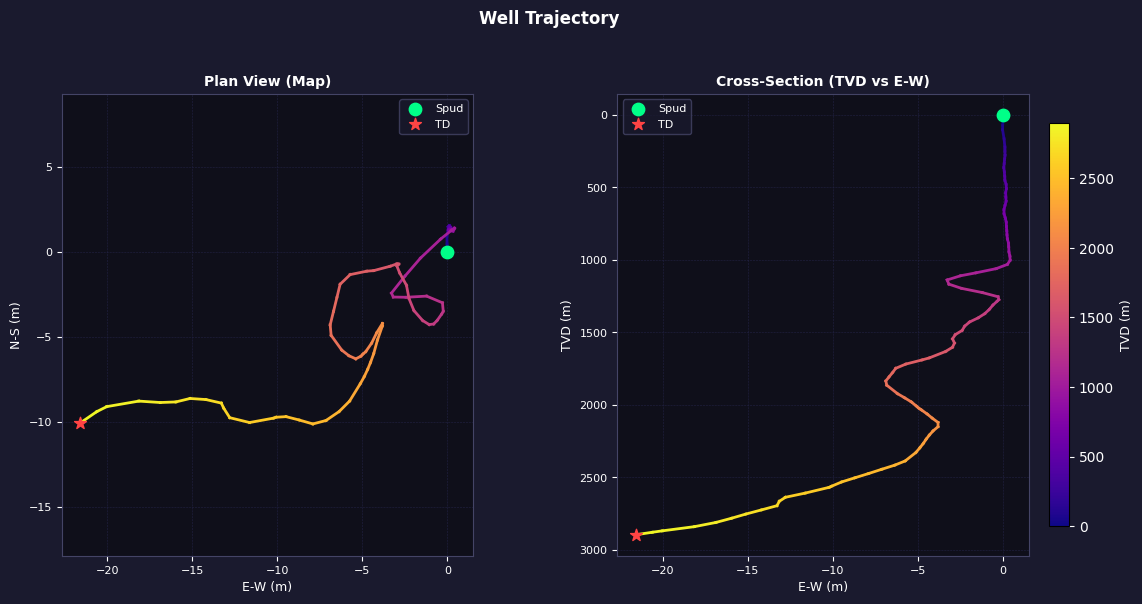

✓ Trajectory plotted


In [50]:
# ── Cell 8: Plot – Well trajectory (map view + depth section) ────────────
# Requires traj_df from Cell 4.

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(13, 6), facecolor="#1a1a2e")
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

ax_map  = fig.add_subplot(gs[0])   # N-S vs E-W  (plan view)
ax_sect = fig.add_subplot(gs[1])   # TVD_m vs E-W (cross-section)

ns  = traj_df["NS_m"].values
ew  = traj_df["EW_m"].values
tvd = traj_df["TVD_m"].values

# ── Colour gradient by depth ──────────────────────────────────────────────────
cmap   = plt.cm.plasma
norm   = plt.Normalize(tvd.min(), tvd.max())
colors = cmap(norm(tvd))

for ax in [ax_map, ax_sect]:
    ax.set_facecolor("#0f0f1a")
    ax.tick_params(colors="white", labelsize=8)
    ax.spines[:].set_color("#444466")
    ax.grid(True, color="#222244", linewidth=0.4, linestyle="--")

# ── Plan view: N-S vs E-W ────────────────────────────────────────────────────
for i in range(len(ns) - 1):
    ax_map.plot(ew[i:i+2], ns[i:i+2], color=colors[i], linewidth=2)

ax_map.scatter(ew[0],  ns[0],  color="#00ff88", s=80, zorder=5, label="Spud")
ax_map.scatter(ew[-1], ns[-1], color="#ff4444", s=80, zorder=5, marker="*", label="TD")
ax_map.set_xlabel("E-W (m)", color="white", fontsize=9)
ax_map.set_ylabel("N-S (m)", color="white", fontsize=9)
ax_map.set_title("Plan View (Map)", color="white", fontsize=10, fontweight="bold")
ax_map.legend(facecolor="#1a1a2e", edgecolor="#444466", labelcolor="white", fontsize=8)
ax_map.set_aspect("equal", adjustable="datalim")

# ── Cross-section: TVD vs E-W ────────────────────────────────────────────────
for i in range(len(ew) - 1):
    ax_sect.plot(ew[i:i+2], tvd[i:i+2], color=colors[i], linewidth=2)

ax_sect.scatter(ew[0],  tvd[0],  color="#00ff88", s=80, zorder=5, label="Spud")
ax_sect.scatter(ew[-1], tvd[-1], color="#ff4444", s=80, zorder=5, marker="*", label="TD")
ax_sect.set_xlabel("E-W (m)", color="white", fontsize=9)
ax_sect.set_ylabel("TVD (m)", color="white", fontsize=9)
ax_sect.set_title("Cross-Section (TVD vs E-W)", color="white", fontsize=10, fontweight="bold")
ax_sect.invert_yaxis()
ax_sect.legend(facecolor="#1a1a2e", edgecolor="#444466", labelcolor="white", fontsize=8)

# ── Colorbar ─────────────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax_map, ax_sect], orientation="vertical",
                    fraction=0.02, pad=0.02)
cbar.set_label("TVD (m)", color="white", fontsize=9)
cbar.ax.yaxis.set_tick_params(color="white", labelcolor="white")

fig.suptitle("Well Trajectory", color="white", fontsize=12,
             fontweight="bold", y=1.02)
plt.show()
print("✓ Trajectory plotted")


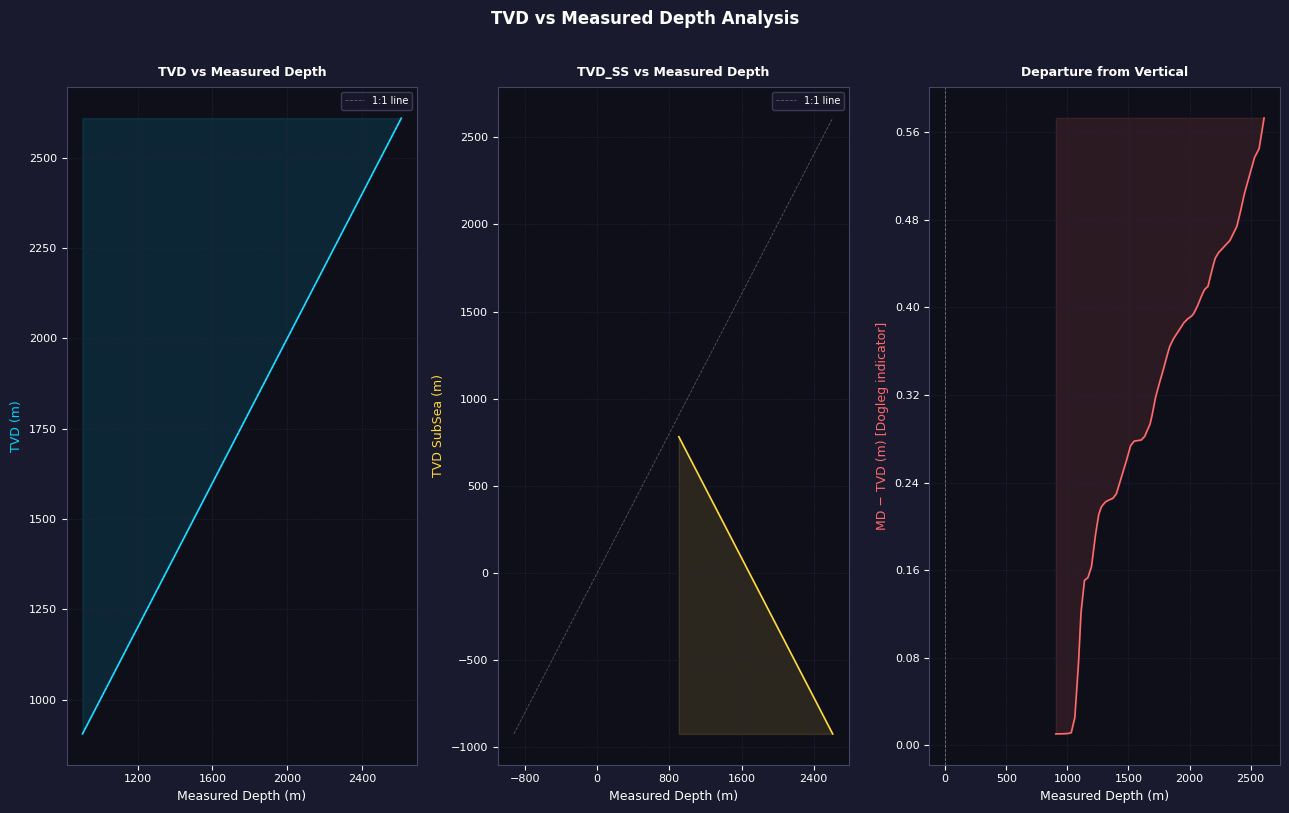

✓ TVD vs Measured Depth plotted


In [51]:
# ── Cell 9: Plot – TVD vs Measured Depth ─────────────────────────────────
# Shows how TVD, TVD_SS diverge from measured depth (deviation indicator).

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(13, 8), facecolor="#1a1a2e")
fig.patch.set_facecolor("#1a1a2e")

configs = [
    ("TVD_m",    depth_m, tvd_m,    "#00d4ff", "TVD (m)",           "TVD vs Measured Depth"),
    ("TVD_SS_m", depth_m, tvd_ss_m, "#ffd93d", "TVD SubSea (m)",    "TVD_SS vs Measured Depth"),
    ("Diff",     depth_m, depth_m - tvd_m, "#ff6b6b", "MD − TVD (m) [Dogleg indicator]", "Departure from Vertical"),
]

for ax, (label, x, y, color, xlabel, title) in zip(axes, configs):
    ax.set_facecolor("#0f0f1a")
    ax.tick_params(colors="white", labelsize=8)
    ax.spines[:].set_color("#444466")
    ax.grid(True, color="#222244", linewidth=0.4, linestyle="--")

    ax.plot(x, y, color=color, linewidth=1.2)
    ax.fill_betweenx(y, x.min(), x, alpha=0.12, color=color)

    ax.set_xlabel("Measured Depth (m)", color="white", fontsize=9)
    ax.set_ylabel(xlabel, color=color, fontsize=9)
    ax.set_title(title, color="white", fontsize=9, fontweight="bold", pad=8)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(8))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(6))

    # 1:1 reference line for first two panels
    if label in ["TVD_m", "TVD_SS_m"]:
        ref_min = min(x.min(), y.min())
        ref_max = max(x.max(), y.max())
        ax.plot([ref_min, ref_max], [ref_min, ref_max],
                color="white", linewidth=0.6, linestyle="--", alpha=0.3, label="1:1 line")
        ax.legend(facecolor="#1a1a2e", edgecolor="#444466",
                  labelcolor="white", fontsize=7)

    # Zero reference line for departure panel
    if label == "Diff":
        ax.axvline(0, color="white", linewidth=0.6, linestyle="--", alpha=0.4)

fig.suptitle("TVD vs Measured Depth Analysis", color="white",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print("✓ TVD vs Measured Depth plotted")
